In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input



X_train = np.load("../data/X_train.npy")
y_train = np.load("../data/y_train.npy")
X_val = np.load("../data/X_val.npy")
y_val = np.load("../data/y_val.npy")
X_test = np.load("../data/X_test.npy")
y_test = np.load("../data/y_test.npy")


scaler_features = joblib.load('../models/scaler_features.joblib')
scaler_target = joblib.load('../models/scaler_target.joblib')

print("libraries and data loaded succesfully")

libraries and data loaded succesfully


In [42]:
# 2. Build the LSTM Model
model = Sequential([
    # Input layer: telling the model the shape of our 7-day windows
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    
    # First LSTM layer: 50 units. return_sequences=False because the next layer is Dense
    LSTM(50, activation='relu', return_sequences=False),
    
    # Dropout: randomly turns off 20% of neurons to prevent "memorization" (overfitting)
    Dropout(0.2),
    
    # Output layer: 1 single neuron (the predicted Max Temp)
    Dense(1)
])

# 3. Compile the model
# optimizer='adam' is the industry standard (it's efficient)
# loss='mse' (Mean Squared Error) measures the distance between prediction and reality
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 50)             │        14,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,251 (55.67 KB)

 Trainable params: 14,251 (55.67 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# 4. Train the model
print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1 # This shows the progress bar
)

Starting training...
Epoch 1/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0072 - val_loss: 0.0046
Epoch 2/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 3/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0042 - val_loss: 0.0042
Epoch 4/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0039 - val_loss: 0.0041
Epoch 5/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0038 - val_loss: 0.0044
Epoch 6/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0037 - val_loss: 0.0039
Epoch 7/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0036 - val_loss: 0.0041
Epoch 8/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0036 - val_loss: 0.0039
Epoch 9/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0036 - val_loss: 0.0038
Epoch 10/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0035 - val_loss: 0.0038
Epoch 11/50
776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - val_loss: 0.0037
Epoch 12/50
776/776 ━━━━━━━━━━━

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os
if not os.path.exists('../models'):
    os.makedirs('../models')

y_pred_scaled = model.predict(X_test)

y_pred = scaler_target.inverse_transform(y_pred_scaled)
y_real = scaler_target.inverse_transform(y_test)

mae = mean_absolute_error(y_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_real, y_pred))

print(f"Erro Médio Absoluto (MAE): {mae:.2f}°C")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.2f}°C")

# Guardar o modelo
model.save('../models/weather_predictor_LSTM.keras')
print("Modelo guardado com sucesso em '../models/weather_predictor_LSTM.keras'")


97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Erro Médio Absoluto (MAE): 2.18°C
Raiz do Erro Quadrático Médio (RMSE): 2.93°C
Modelo guardado com sucesso em '../models/weather_predictor_LSTM.keras'


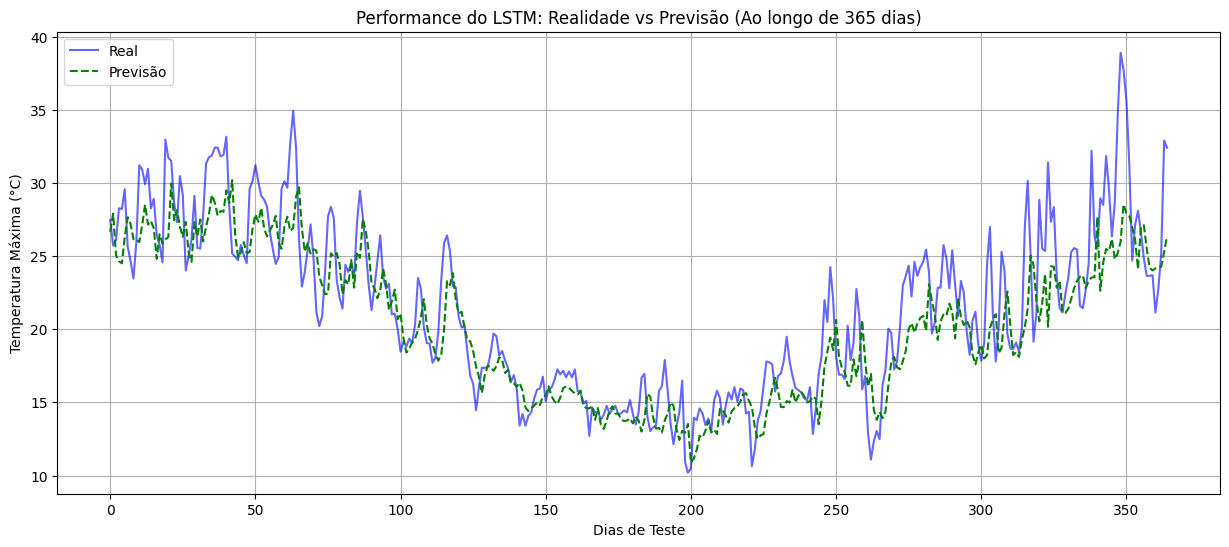

In [52]:
#Criar figura
plt.figure(figsize=(15, 6))
plt.plot(y_real[:365], label='Real', color='blue', alpha=0.6)
plt.plot(y_pred[:365], label='Previsão', color='green', linestyle='--')
plt.title('Performance do LSTM: Realidade vs Previsão (Ao longo de 365 dias)')
plt.xlabel('Dias de Teste')
plt.ylabel('Temperatura Máxima (°C)')
plt.legend()
plt.grid(True)
plt.show()